# Initial Setup

In [1]:
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain.agents import initialize_agent, tool
from langchain_community.tools import TavilySearchResults ## Note that this is deprecated now in favour of TavilySearch used elsewhere in the notebook. I'm only showing for demonstration purpose in this section
import datetime, os, getpass

In [2]:
load_dotenv(override=True)

True

In [3]:
#Check for environment variables
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

In [4]:
#Make sure this exists
_set_env("OPENAI_API_KEY")

# Basic ReACT Agent

In [5]:
model_name = "gpt-4o-mini"
llm = ChatOpenAI(
    model = model_name
#     temperature=0,
#     max_tokens=None,
#     timeout=None,
#     max_retries=2,
)

In [6]:
search_tool = TavilySearchResults(search_depth="basic") ## Note that this is deprecated now in favour of TavilySearch used elsewhere in the notebook. I'm only showing for demonstration purpose in this section

In [7]:
@tool
def get_system_time(format: str = "%Y-%m-%d %H:%M:%S"):
    """ Returns the current date and time in the specified format """

    current_time = datetime.datetime.now()
    formatted_time = current_time.strftime(format)
    return formatted_time

In [8]:
tools = [search_tool, get_system_time]

In [9]:
#LangChain's in-built class using initialize_agent and AgentExecutor
agent = initialize_agent(tools=tools, llm=llm, agent="zero-shot-react-description", verbose=True)

/var/folders/lf/hqk7z7j55856d37927df0b2w0000gn/T/ipykernel_94154/948111834.py:2: LangChainDeprecationWarning: LangChain agents will continue to be supported, but it is recommended for new use cases to be built with LangGraph. LangGraph offers a more flexible and full-featured framework for building agents, including support for tool-calling, persistence of state, and human-in-the-loop workflows. For details, refer to the `LangGraph documentation <https://langchain-ai.github.io/langgraph/>`_ as well as guides for `Migrating from AgentExecutor <https://python.langchain.com/docs/how_to/migrate_agent/>`_ and LangGraph's `Pre-built ReAct agent <https://langchain-ai.github.io/langgraph/how-tos/create-react-agent/>`_.
  agent = initialize_agent(tools=tools, llm=llm, agent="zero-shot-react-description", verbose=True)


In [10]:
agent.invoke("What is TrueFoundry?")



> Entering new AgentExecutor chain...
I need to gather information about TrueFoundry, which could be a company, product, or service. I'll search for the latest and most accurate details regarding it. 
Action: tavily_search_results_json
Action Input: "TrueFoundry" 
Observation: [{'title': 'TrueFoundry - GitHub', 'url': 'https://github.com/truefoundry', 'content': 'TrueFoundry is a cloud-agnostic PaaS running on Kubernetes that standardizes model training & deployments for ML/LLMs using developer-friendly APIs.', 'score': 0.9466806}, {'title': 'TrueFoundry - Crunchbase Company Profile & Funding', 'url': 'https://www.crunchbase.com/organization/truefoundry', 'content': 'TrueFoundry is an enterprise platform that helps enterprise teams build, deploy, and manage large language model applications at scale.', 'score': 0.9240941}, {'title': 'TrueFoundry Reviews & Product Details - G2', 'url': 'https://www.g2.com/products/truefoundry/reviews', 'content': 'TrueFoundry is a cloud-native PaaS th

{'input': 'What is TrueFoundry?',
 'output': 'TrueFoundry is a cloud-native Platform as a Service (PaaS) designed for machine learning (ML) teams. It enables organizations to build, deploy, and manage large language model (LLM) applications in a scalable and efficient manner, often enhancing productivity by 90%. TrueFoundry is cloud-agnostic and abstracts the engineering complexities involved in ML workflows, offering various developer-friendly APIs and GenAI accelerators. The company, founded in 2021, is backed by notable investors, including Sequoia Capital, and works with several Fortune 500 companies. More information can be found on their [website](https://truefoundry.com/).'}

# Basic Reflection Agent

## For Tracing

In [11]:
# #Set the following env variables
# LANGSMITH_TRACING="true"
# LANGSMITH_ENDPOINT="https://api.smith.langchain.com"
# LANGSMITH_API_KEY="<your-api-key>"
# LANGSMITH_PROJECT="module4-building-agents-with-langgraph"

In [12]:
#Reload the environment variables
load_dotenv(override=True)

True

In [13]:
#Checks
_set_env("LANGSMITH_TRACING")
_set_env("LANGSMITH_ENDPOINT")
_set_env("LANGSMITH_API_KEY")
_set_env("LANGSMITH_PROJECT")

**All invocations of LangChain runnables within your applications are automatically traced, by setting the above environment variables. For other scenarios, there are other ways to do this.**

## Back to Reflection Agent

In [14]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from typing import List, Sequence
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import StateGraph, END, MessagesState

In [15]:
model_name = "gpt-4o-mini"
llm = ChatOpenAI(
    model = model_name
#     temperature=0,
#     max_tokens=None,
#     timeout=None,
#     max_retries=2,
)

In [16]:
generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a twitter techie influencer assistant tasked with writing excellent twitter posts."
            " Generate the best twitter post possible for the user's request."
            " If the user provides critique, respond with a revised version of your previous attempts.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [17]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a viral twitter influencer grading a tweet. Your task is to critique the user's tweet."
            " Provide a few recommendations in less than a line for improvement. If the tweet is excellent and no more revisions are needed, end your critique with the word 'STOP'."
            " If more revisions are needed, end your critique with the word 'REVISE'.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

The most common use case for `MessagesPlaceholder` is for managing and injecting chat history. In a multi-turn conversation, you don't just want the AI to respond to the user's last message; you want it to have the full context of the conversation so far.

The `variable_name="messages"` tells the `ChatPromptTemplate` to look for a key named "messages" in the input dictionary when the prompt is invoked. The value associated with this key should be a list of `BaseMessage` objects (e.g., `HumanMessage`, `AIMessage`, `SystemMessage`, etc.).

In [18]:
generation_chain = generation_prompt | llm
reflection_chain = reflection_prompt | llm

In [19]:
REFLECT = "reflect"
GENERATE = "generate"

In [20]:
#Define generate node
def generate_node(state: MessagesState):
    response = generation_chain.invoke({
        "messages": state['messages']
    })
    return {"messages": [response]} # Return a dictionary with the new message to append to the state.

The `MessagesState` in LangGraph is a `TypedDict` that specifically manages a list of messages. It's designed to automatically handle message accumulation. Under the hood, it uses the `add_messages` reducer to append new messages to the existing list.

In [21]:
#Define reflect node
def reflect_node(state: MessagesState):
    last_ai_message = state["messages"][-1]
    response = reflection_chain.invoke({"messages": [last_ai_message]})
    
    return {"messages": [HumanMessage(content=response.content)]}

In [22]:
def should_continue(state: MessagesState):
    """
    Determines whether to continue the reflection loop based on the last critique.
    
    The reflection LLM is prompted to end its response with 'STOP' or 'REVISE'.
    We check for this signal.
    """
    last_message = state["messages"][-1]
    if "STOP" in last_message.content.upper():
        return "end"  # The critique says the tweet is good, so we end.
    elif (len(state["messages"]) > 6):
        return "end"
    else:
        return "generate"  # The critique says to revise, so we go back to the generate node.

In [23]:
#Create graph
graph = StateGraph(MessagesState)

#Add nodes
graph.add_node(GENERATE, generate_node)
graph.add_node(REFLECT, reflect_node)

#Set the entry point
graph.set_entry_point(GENERATE)

#Add edges
graph.add_edge(GENERATE, REFLECT)
graph.add_conditional_edges(REFLECT, 
                            should_continue,
                           {
                               "generate": GENERATE,
                               "end": END
                           })

app = graph.compile()

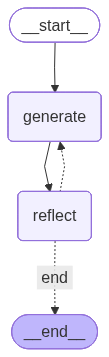

In [24]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [25]:
response = app.invoke({"messages":[HumanMessage(content="1 line on Indo-US relations")]})

print(response)

{'messages': [HumanMessage(content='1 line on Indo-US relations', additional_kwargs={}, response_metadata={}, id='2567b826-ecdf-468c-a770-147dd9a3d84e'), AIMessage(content='🌏 The evolving Indo-US relations are a testament to shared democratic values, strategic partnerships, and a mutual commitment to a peaceful, prosperous future. 🇮🇳🤝🇺🇸 #IndoUSRelations #GlobalPartnerships', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 59, 'total_tokens': 108, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CG0f4LfyHnhgAm0cVj6dGLlb5BuMH', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--fe65d977-ebe6-4490-ab8c-8ae15f632700-0', usage_metadata={'input_tokens

In [26]:
# ## IN-SESSIONEXERCISE - SPOT THE ERRORS
# #Create graph
# graph = StateGraph(MessagesState)

# #Add nodes
# graph.add_node(GENERATE, generate_node)
# graph.add_node(REFLECT, reflect_node)

# #Set the entry point
# graph.set_entry_point(GENERATE)

# #Add edges
# graph.add_conditional_edges(GENERATE, should_continue)
# graph.add_edge(REFLECT, GENERATE)

# app = graph.compile()

# display(Image(app.get_graph(xray=True).draw_mermaid_png()))

## Inspect Tracing on LangSmith

# State Deep-Dive

## Simple Implementation

In [111]:
from typing import TypedDict
from langgraph.graph import END, StateGraph

In [ ]:
class SimpleState(TypedDict):
    count: int

In [114]:
def increment(state: SimpleState) -> SimpleState: 
    return {
        "count": state["count"] + 1
    }

In [115]:
def should_continue(state):
    if(state["count"] < 5): 
        return "continue"
    else: 
        return "stop"

In [116]:
#Initialize graph
graph = StateGraph(SimpleState)

#Add node
graph.add_node("increment", increment)

#Set entry point
graph.set_entry_point("increment")

# Add edges
graph.add_conditional_edges(
    "increment", 
    should_continue, 
    {
        "continue": "increment", 
        "stop": END
    }
)

# Compile
app = graph.compile()

In [117]:
state = {
    "count": 0
}

result = app.invoke(state)
print(result)

{'count': 5}


## Better Implementation

In the LangChain framework, `Annotated` is used with `TypedDict` to define how a state variable should be updated within a graph. Specifically, it allows you to specify an operator (like `operator.add` or `operator.concat`) that determines how the new value for that key is combined with the old value.

In [27]:
from typing import TypedDict, List, Annotated
from langgraph.graph import END, StateGraph
import operator

In [28]:
#Define a complex state with annotations
class ComplexState(TypedDict):
    count: int
    total_sum: Annotated[int, operator.add]
    history: Annotated[List[int], operator.concat]

In [29]:
#Define a node to update the state
def increment(state: ComplexState) -> ComplexState:
    new_count = state["count"] + 1
    
    # Return updates for each key. LangGraph handles the merging.
    return {
        "count": new_count,
        "total_sum": new_count, # LangGraph will add this to the total_sum
        "history": [new_count]  # LangGraph will concatenate this to the history list
    }

In [30]:
#Define a condition for the loop
def should_continue(state: ComplexState):
    if state["count"] < 5:
        return "continue"
    else:
        return "stop"
    

In [31]:
#Build and compile the graph
graph = StateGraph(ComplexState)
graph.add_node("increment", increment)
graph.set_entry_point("increment")
graph.add_conditional_edges(
    "increment",
    should_continue,
    {
        "continue": "increment",
        "stop": END
    }
)
app = graph.compile()

In [32]:
#Run the graph with an initial state
state = {
    "count": 0,
    "total_sum": 0,
    "history": []
}
result = app.invoke(state)
print(result)

{'count': 5, 'total_sum': 15, 'history': [1, 2, 3, 4, 5]}


# ReACT Agent using LangGraph - Part 1

- Why do we want to use LangGraph instead of in-built LangChain `initialize_agent` function? This is due to the infinite loop problem and want of more control.

- LangChain `initialize_agent` function combines two key components - `create_react_agent` and `AgentExecutor` class (we will eliminate AgentExecutor with LangGraph). AgentExecutor controls the looping between LangChain and LLM.

- What `create_react_agent` does -> Thought, action, action input and parses that into one of the 2 classes - `AgentAction` and `AgentFinish`

- What `AgentExecutor` does -> Takes agent from `create_react_agent` and manages execution loop; receives user's question and feeds to agent

In [38]:
from langchain.agents import tool, create_react_agent
from langgraph.graph import END, StateGraph
import datetime
from langchain_tavily import TavilySearch
from langchain import hub

## Reasoning Runnable

In [39]:
@tool
def get_system_time(format: str = "%Y-%m-%d %H:%M:%S"):
    """ Returns the current date and time in the specified format """

    current_time = datetime.datetime.now()
    formatted_time = current_time.strftime(format)
    return formatted_time

In [40]:
search_tool = TavilySearch(search_depth="basic") #new version that should be used

In [41]:
react_prompt = hub.pull("hwchase17/react")

In [43]:
print(react_prompt.template)

Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}


In [44]:
tools = [get_system_time, search_tool]

In [45]:
react_agent_runnable = create_react_agent(tools=tools, llm=llm, prompt=react_prompt)

## State

In [46]:
import operator
from typing import Annotated, TypedDict, Union
from langchain_core.agents import AgentAction, AgentFinish

In [48]:
class AgentState(TypedDict):
    input: str
    agent_outcome: Union[AgentAction, AgentFinish, None]
    intermediate_steps: Annotated[list[tuple[AgentAction, str]], operator.add]

## Building Nodes

In [49]:
def reason_node(state: AgentState):
    agent_outcome = react_agent_runnable.invoke(state)
    return {"agent_outcome": agent_outcome}

In [50]:
def act_node(state: AgentState):
    agent_action = state["agent_outcome"]
    
    ## ----- Since ToolExecutor is deprecated ----- START -----
    ## Else just do: output = tool_executor.invoke(agent_action)
    
    # Extract tool name and input from AgentAction
    tool_name = agent_action.tool
    tool_input = agent_action.tool_input
    
    # Find the matching tool function
    tool_function = None
    for tool in tools:
        if tool.name == tool_name:
            tool_function = tool
            break
    
    # Execute the tool with the input
    if tool_function:
        if isinstance(tool_input, dict):
            output = tool_function.invoke(**tool_input)
        else:
            output = tool_function.invoke(tool_input)
    else:
        output = f"Tool '{tool_name}' not found"
    
    ## ----- Since ToolExecutor is deprecated ----- END -----
    
    return {"intermediate_steps": [(agent_action, str(output))]}

## Final Graph

In [51]:
REASON_NODE = "reason_node"
ACT_NODE = "act_node"

In [52]:
def should_continue(state: AgentState) -> str:
    if isinstance(state["agent_outcome"], AgentFinish):
        return "end"
    else:
        return "act"

In [53]:
graph = StateGraph(AgentState)

graph.add_node(REASON_NODE, reason_node)
graph.add_node(ACT_NODE, act_node)

graph.set_entry_point(REASON_NODE)

graph.add_conditional_edges(
    REASON_NODE,
    should_continue,
    {
        "act": ACT_NODE,
        "end": END
    }
)

graph.add_edge(ACT_NODE, REASON_NODE)

app = graph.compile()

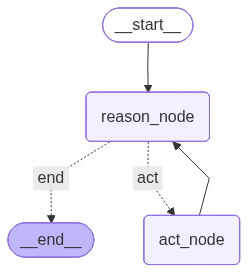

In [54]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [55]:
result = app.invoke(
    {
        "input": "How many years ago was the last Hackathon at TrueFoundry?", 
        "agent_outcome": None, 
        "intermediate_steps": []
    }
)

print(result["agent_outcome"].return_values["output"], "This is the final result.")

Approximately 2 years ago, the last Hackathon at TrueFoundry occurred in July 2023. This is the final result.


**Explore tracing the graph using LangSmith.**

In [65]:
# #Invoke and inspect for non LangChain
# from langsmith import traceable
# @traceable
# def get_response(question):
#     result = app.invoke(
#         {
#             "input": question, 
#             "agent_outcome": None, 
#             "intermediate_steps": []
#         }
#     )

#     return(result["agent_outcome"].return_values["output"], "This is the final result.")
# get_response("How many years ago was the last Hackathon at TrueFoundry?")

# ReACT Agent using LangGraph - Part 2

**This is recommended by LangChain to be the most production-ready way to do it.**

In [66]:
from langgraph.prebuilt import create_react_agent

In [67]:
#Initialize the agent
agent = create_react_agent(
    model=model_name,  
    tools=tools,  
    prompt="You are a helpful assistant"  
)

In [68]:
# Run the agent
agent.invoke(
    {"messages": [{"role": "user", "content": "How many years ago was the last Hackathon at TrueFoundry?"}]}
)

{'messages': [HumanMessage(content='How many years ago was the last Hackathon at TrueFoundry?', additional_kwargs={}, response_metadata={}, id='dd4473b8-d1fe-4707-ae99-38716e4803aa'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_OUXN04RsWz0R8EwNcNtKwkv9', 'function': {'arguments': '{"query":"TrueFoundry hackathon date"}', 'name': 'tavily_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1331, 'total_tokens': 1352, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CFxyToQrONqu6w6sJZG6qmROSOfWM', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b86c00f7-5588-400b-b857-ea36d165e4ca-0', tool_calls=[{'name'

**Explore tracing the graph using LangSmith.**

## Add memory

In [69]:
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import InMemorySaver

### Issue without memory

In [70]:
agent = create_react_agent(
    model=model_name,
    tools=tools)

In [71]:
first_response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is TrueFoundry all about?"}]})

In [72]:
second_response = agent.invoke(
    {"messages": [{"role": "user", "content": "What's unique about it?"}]})

In [73]:
second_response

{'messages': [HumanMessage(content="What's unique about it?", additional_kwargs={}, response_metadata={}, id='1af0b944-389f-445e-b742-a04ec5c2a187'),
  AIMessage(content='Could you please specify what you are referring to? Are you asking about a specific topic, product, place, or something else?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1316, 'total_tokens': 1343, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CFxyxornxdXNjB3eFlRrIY7dUe7DV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--8f77e21d-fa6c-4563-b5f3-bcfcef535efd-0', usage_metadata={'input_tokens': 1316, 'output_tokens': 27, 'total_tokens': 1343, 'input_token_details': {

### Resolved by memory

To enable multi-turn conversations with an agent, we need to 

1. **Enable persistence** by providing a **checkpointer** when creating an agent. Checkpoints save the complete state after a node finishes its work.

2. At runtime, we need to provide a config containing **thread_id** — which is simply a unique identifier for each specific conversation or workflow execution (session). This is important because there can be simultaneously running conversations/workflows.

In [74]:
checkpointer = InMemorySaver()

In [75]:
agent = create_react_agent(
    model=model_name,
    tools=tools,
    checkpointer=checkpointer  
)

In [76]:
# Run the agent
config = {"configurable": {"thread_id": "1"}}

In [77]:
first_response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is TrueFoundry all about?"}]},
    config  
)

In [78]:
second_response = agent.invoke(
    {"messages": [{"role": "user", "content": "What's unique about it?"}]},
    config
)

In [79]:
second_response

{'messages': [HumanMessage(content='What is TrueFoundry all about?', additional_kwargs={}, response_metadata={}, id='a2236c67-bbc7-4f23-b5d2-198053aa607b'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_nAOB21msVf368mmwiIb4GCx7', 'function': {'arguments': '{"query":"TrueFoundry","search_depth":"advanced"}', 'name': 'tavily_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 1319, 'total_tokens': 1342, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1280}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CFxyyUPDfbZTk4sFcbtf6TKaosO9m', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--d0cb9015-338e-4e11-8d6a-700a8be0d6d7-0', tool_calls=[{'name': 'tavily_sea

## Configure structured output

In [56]:
from pydantic import BaseModel, Field
from langgraph.prebuilt import create_react_agent

In [57]:
class KeyEntities(BaseModel):
    entities: str = Field(description="Key named entities in the piece of text")

In [58]:
agent = create_react_agent(
    model=model_name,
    tools=tools,
    response_format=KeyEntities  
)

In [59]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What's happening in Indo-US relations currently?"}]}
)

response["structured_response"]

KeyEntities(entities='Donald Trump, Narendra Modi, U.S., India, trade negotiations, tariffs, defense cooperation, markets, India-Pakistan conflict')

In [ ]:
#Perform model_dump() to get the structured output in a dictionary format
response["structured_response"].model_dump()

{'entities': 'Donald Trump, Narendra Modi, U.S., India, trade negotiations, tariffs, defense cooperation, markets, India-Pakistan conflict'}